# Geo-Experiment Tools: A Pedagogical Walkthrough

This notebook is a companion to the Monte Carlo simulation study comparing four geo-experiment causal inference tools:

| Tool | Method |
|------|--------|
| **Meta GeoLift** | Augmented Synthetic Control (Ridge + block conformal inference) |
| **CausalPy** | Bayesian Synthetic Control (Dirichlet-weighted, PyMC backend) |
| **Google Matched Markets** | Time-Based Regression (TBR, OLS) |
| **Google CausalImpact** | Bayesian Structural Time Series (BSTS) |

Rather than running 1,000 Monte Carlo iterations, this notebook generates **one synthetic panel per scenario** from a Python-native DGP, runs all four tools on the selected panel, and compares their estimates side-by-side.

**Prerequisites:** activate the `.venv` created by `make env`, and ensure the R environment is set up (`make env` from the repo root installs R packages via `renv::restore()`).

---
**Run order:** Execute cells top-to-bottom. To try a different scenario or effect, change `SCENARIO`/`EFFECT` in Section 0 and re-run from Section 3 onward.

## 0  Configuration

All user-tunable parameters live here. `SCENARIO` and `EFFECT` control which panel is fed to the four tools in Sections 4–7. Sampler settings trade speed for posterior quality — the defaults run in a few minutes; production settings (`N_CHAINS=4`, `N_DRAWS=1000`) take much longer.

In [1]:
# ── Sampler settings (CausalPy only — other tools are deterministic) ──────────
# Increase for publication-quality posteriors at the cost of runtime.
N_CHAINS      = 2      # 4 in the production study
N_DRAWS       = 500    # 1000 in the production study
N_WARMUP      = 500    # 1000 in the production study
TARGET_ACCEPT = 0.80   # HMC step-size target

# ── Which panel to analyze in Sections 4–8 ────────────────────────────────────
SCENARIO = 'A1'      # 'A1' (textbook) | 'A2' (outlier 5x) | 'A3' (small pool) | 'A4' (short pre)
EFFECT   = 'effect'  # 'effect' (7.5% lift) | 'null' (0% -- false-positive check)
SEED     = 42

In [2]:
import os
import sys
import json
import subprocess
import tempfile
import warnings
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ── Resolve repo root (works from repo root or notebooks/ subdirectory) ───────
_cwd = Path('.').resolve()
if (_cwd / 'src').exists():
    repo_root = _cwd
elif (_cwd.parent / 'src').exists():
    repo_root = _cwd.parent
else:
    raise RuntimeError(
        'Cannot locate repo root. Run this notebook from the repository root '
        'or the notebooks/ directory.'
    )
os.chdir(repo_root)  # ensures R subprocess paths (src/R/*.R) resolve correctly
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.python.compute_att import compute_true_att, check_coverage
from src.python.data_converters import (
    to_causalpy_format,
    to_google_mm_format,
    to_geolift_format,
)
from src.python.run_causalpy import run_causalpy
from src.python.run_google_mm import run_google_mm

print(f'Repo root: {repo_root}')
print('All imports successful.')

Repo root: /Users/mari/Documents/repo/geolift-simulation-study
All imports successful.


## 1  Data Generating Process (DGP)

This is a Python port of `src/R/generate_panels.R`. The DGP for each geo *i* at time *t* is:

```
Y_cf[i,t] = baseline[i] * trend[t] * season[t] * exp(noise_level * scale_i * ar_noise[i,t])
```

where:
- `baseline[i]` ~ LogNormal (mean=4000, sdlog=0.6) — geo market size
- `trend[t]   = 1 + 0.001 * t` — 0.1%/day multiplicative growth, shared across all geos
- `season[t]  = 1 + 0.10 * dow_profile[(t-1) % 7]` — day-of-week effect, shared
- `ar_noise[i,t] = 0.30 * ar_noise[i,t-1] + z[i,t]` — AR(1) noise, independent per geo
- `scale_i    = sqrt(baseline[i] / mean_baseline)` — bigger geos get proportionally **less** noise per unit (portfolio effect: 4x larger geo → 2x the noise amplitude, not 4x)
- `exp(...)` ensures Y is always strictly positive regardless of noise magnitude

**Treatment** (post-period, treated geo only):
```
Y[i,t] = Y_cf[i,t] * (1 + effect_pct)   for treated geo, t >= treatment_start
```

The true counterfactual `Y_counterfactual` is stored alongside `Y` and serves as the ground truth for coverage and bias evaluation.

**Null and effect panels share the same noise draws** — only the post-period lift differs. This isolates treatment effect estimation from sampling variation in the pre-period.

In [3]:
# ── DGP parameters (matching generate_panels.R exactly) ──────────────────────
BASELINE_MEAN      = 4000
BASELINE_SPREAD    = 0.6      # sdlog of the log-normal baseline distribution
TREND_SLOPE        = 0.001    # multiplicative daily growth (0.1%/day)
SEASONALITY_AMP    = 0.10     # +/-10% day-of-week variation
DOW_PROFILE        = np.array([-1.0, -0.5, 0.0, 0.2, 0.8, 1.0, 0.5])  # Mon-Sun
AUTOCORRELATION    = 0.30     # AR(1) coefficient
NOISE_LEVEL        = 0.20     # log-scale noise magnitude
OUTLIER_MULTIPLIER = 5.0      # baseline inflation factor for scenario A2
MASTER_SEED        = 42

SCENARIO_DEFS = {
    'A1': dict(n_control=20, total_days=105, pre_days=90, outlier=False),
    'A2': dict(n_control=20, total_days=105, pre_days=90, outlier=True),
    'A3': dict(n_control=9,  total_days=105, pre_days=90, outlier=False),
    'A4': dict(n_control=20, total_days=45,  pre_days=30, outlier=False),
}
EFFECT_SIZES = {'null': 0.0, 'effect': 0.075}


def draw_baselines(n_geos, rng):
    """Draw geo baselines from LogNormal with mean=BASELINE_MEAN.

    R: rlnorm(n, meanlog = log(mu) - sdlog^2/2, sdlog = BASELINE_SPREAD)
    """
    meanlog = np.log(BASELINE_MEAN) - BASELINE_SPREAD**2 / 2
    return np.sort(rng.lognormal(mean=meanlog, sigma=BASELINE_SPREAD, size=n_geos))


def select_treated(baselines):
    """Return index of the geo whose baseline is closest to the median."""
    return int(np.argmin(np.abs(baselines - np.median(baselines))))


def generate_panel(baselines, treated_idx, effect_pct,
                   total_days, pre_days, noise_baselines, rng):
    """Generate one synthetic geo-level panel.

    noise_baselines: baseline vector used for noise scaling only.
        For A2, this is the PRE-inflation baselines so the 5x outlier
        inflation does not also inflate the noise amplitude.

    Returns long-format DataFrame: geo, date, Y, Y_counterfactual, treated.
    """
    n_geos = len(baselines)
    t = np.arange(1, total_days + 1)
    trend  = 1.0 + TREND_SLOPE * t
    season = 1.0 + SEASONALITY_AMP * DOW_PROFILE[(t - 1) % 7]
    mean_baseline = noise_baselines.mean()

    Y_cf = np.zeros((total_days, n_geos))
    for i in range(n_geos):
        scale_i = np.sqrt(noise_baselines[i] / mean_baseline)
        innovations = rng.standard_normal(total_days)
        ar_noise = np.zeros(total_days)
        ar_noise[0] = innovations[0]
        for tt in range(1, total_days):
            ar_noise[tt] = AUTOCORRELATION * ar_noise[tt - 1] + innovations[tt]
        Y_cf[:, i] = (
            baselines[i] * trend * season
            * np.exp(NOISE_LEVEL * scale_i * ar_noise)
        )

    Y = Y_cf.copy()
    Y[pre_days:, treated_idx] = Y_cf[pre_days:, treated_idx] * (1 + effect_pct)

    geo_names = [f'City {i + 1}' for i in range(n_geos)]
    rows = [
        {
            'geo': geo_names[i],
            'date': tt + 1,
            'Y': float(Y[tt, i]),
            'Y_counterfactual': float(Y_cf[tt, i]),
            'treated': bool(i == treated_idx),
        }
        for i in range(n_geos)
        for tt in range(total_days)
    ]
    return pd.DataFrame(rows)

In [4]:
panels = {}

for sc_id, sc in SCENARIO_DEFS.items():
    sc_idx = list(SCENARIO_DEFS).index(sc_id)
    # Seed mirrors generate_panels.R: master_seed * 1000 + sc_index * 10000 + iteration
    panel_seed = MASTER_SEED * 1000 + (sc_idx + 1) * 10000 + 1

    rng_b = np.random.default_rng(panel_seed)
    n_geos = 1 + sc['n_control']
    baselines = draw_baselines(n_geos, rng_b)
    noise_baselines = baselines.copy()  # pre-inflation copy for noise scaling
    treated_idx = select_treated(baselines)

    if sc['outlier']:
        # A2: inflate treated geo 5x AFTER selection (convex hull violation for SC methods)
        baselines[treated_idx] *= OUTLIER_MULTIPLIER

    panels[sc_id] = {}
    for eff_label, eff_pct in EFFECT_SIZES.items():
        # Re-seed with the same noise seed so null and effect panels have
        # identical pre-treatment data -- only the post-period lift differs.
        rng_p = np.random.default_rng(panel_seed + 100_000)
        panels[sc_id][eff_label] = generate_panel(
            baselines=baselines,
            treated_idx=treated_idx,
            effect_pct=eff_pct,
            total_days=sc['total_days'],
            pre_days=sc['pre_days'],
            noise_baselines=noise_baselines,
            rng=rng_p,
        )

print('Panels generated:')
for sc_id in panels:
    for eff in panels[sc_id]:
        df = panels[sc_id][eff]
        print(
            f'  {sc_id}/{eff}: {df["geo"].nunique()} geos x '
            f'{df["date"].nunique()} days = {len(df):,} rows'
        )

Panels generated:
  A1/null: 21 geos x 105 days = 2,205 rows
  A1/effect: 21 geos x 105 days = 2,205 rows
  A2/null: 21 geos x 105 days = 2,205 rows
  A2/effect: 21 geos x 105 days = 2,205 rows
  A3/null: 10 geos x 105 days = 1,050 rows
  A3/effect: 10 geos x 105 days = 1,050 rows
  A4/null: 21 geos x 45 days = 945 rows
  A4/effect: 21 geos x 45 days = 945 rows


In [5]:
df

,geo,date,Y,Y_counterfactual,treated
0,City 1,1,481.074848,481.074848,False
1,City 1,2,496.379242,496.379242,False
2,City 1,3,590.503980,590.503980,False
3,City 1,4,527.235698,527.235698,False
4,City 1,5,542.666820,542.666820,False
...,...,...,...,...,...
940,City 21,41,8912.896212,8912.896212,False
941,City 21,42,10940.699727,10940.699727,False
942,City 21,43,6738.500453,6738.500453,False
943,City 21,44,6874.819976,6874.819976,False


## 2  Visualizing the Four Scenarios

Each subplot shows the **null condition** (0% lift) for one scenario. The dashed vertical line marks the start of the treatment window — even though there's no actual effect here, the window is where the tools will later estimate an ATT.

- **A1**: Clean, well-behaved donor pool — the easiest case for all tools
- **A2**: The treated geo (coral) is inflated 5x, putting it far outside the convex hull of donors — synthetic control methods struggle here
- **A3**: Fewer control geos means less information for the counterfactual
- **A4**: Only 30 pre-treatment days to calibrate on instead of 90

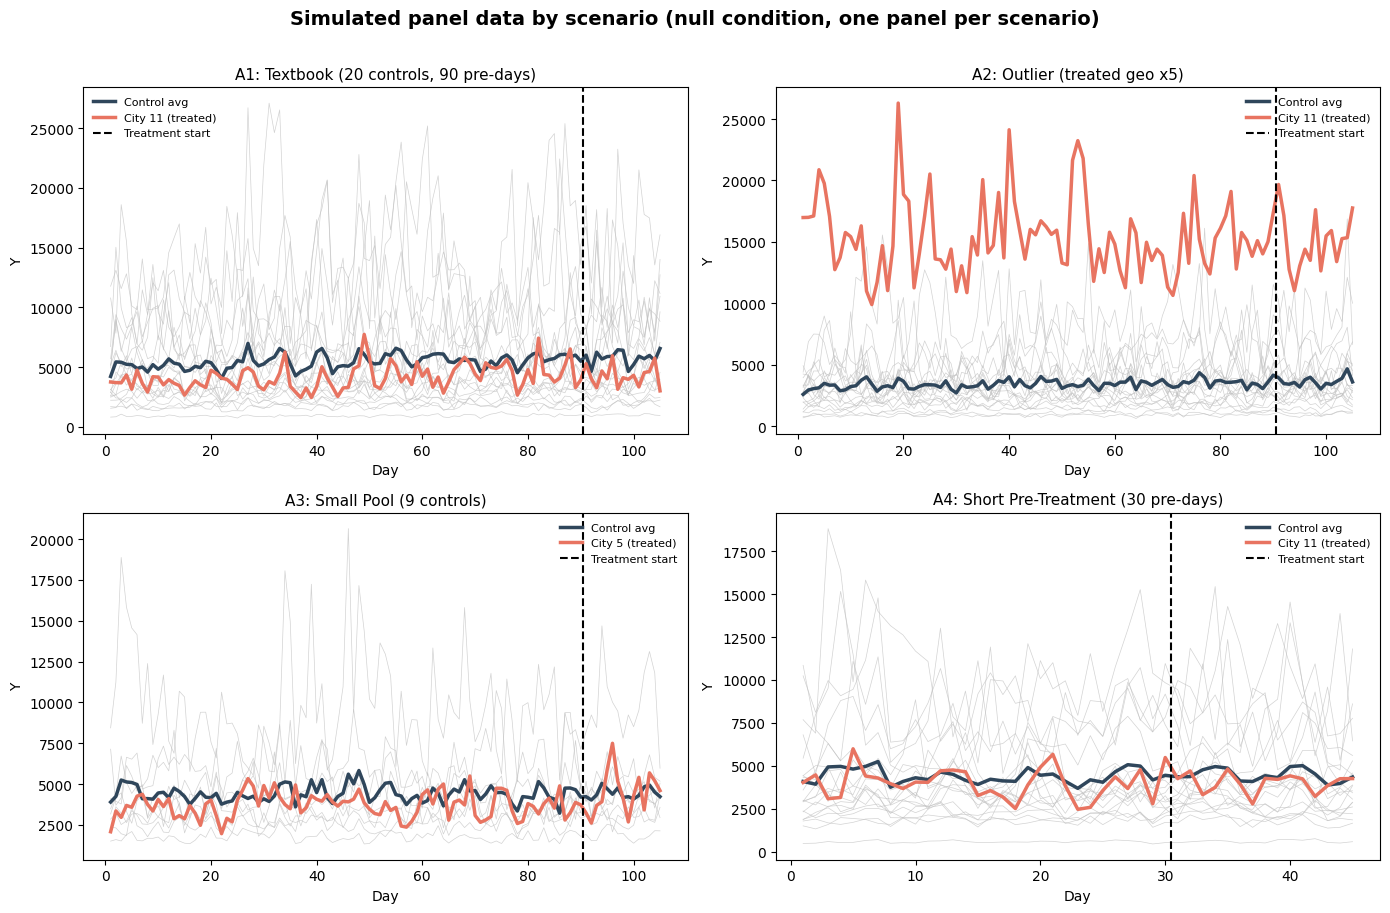

In [6]:
SCENARIO_LABELS = {
    'A1': 'A1: Textbook (20 controls, 90 pre-days)',
    'A2': 'A2: Outlier (treated geo x5)',
    'A3': 'A3: Small Pool (9 controls)',
    'A4': 'A4: Short Pre-Treatment (30 pre-days)',
}
COL_CTRL_IND = '#c0c0c0'
COL_CTRL_AVG = '#2f465b'
COL_TREATED  = '#E87461'
COL_VLINE    = 'black'

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Simulated panel data by scenario (null condition, one panel per scenario)',
    fontsize=14, fontweight='bold', y=1.01,
)

for ax, (sc_id, sc) in zip(axes.flat, SCENARIO_DEFS.items()):
    df_plot = panels[sc_id]['null']
    treatment_start_vline = sc['pre_days'] + 0.5

    treated_geo  = df_plot[df_plot['treated']]['geo'].iloc[0]
    control_geos = [g for g in df_plot['geo'].unique() if g != treated_geo]

    for geo in control_geos:
        gd = df_plot[df_plot['geo'] == geo].sort_values('date')
        ax.plot(gd['date'], gd['Y'], color=COL_CTRL_IND, lw=0.5, alpha=0.7)

    ctrl_avg = (
        df_plot[df_plot['geo'].isin(control_geos)]
        .groupby('date')['Y'].mean()
    )
    ax.plot(ctrl_avg.index, ctrl_avg.values, color=COL_CTRL_AVG, lw=2.5,
            label='Control avg')

    td = df_plot[df_plot['geo'] == treated_geo].sort_values('date')
    ax.plot(td['date'], td['Y'], color=COL_TREATED, lw=2.5,
            label=f'{treated_geo} (treated)')

    ax.axvline(treatment_start_vline, color=COL_VLINE, lw=1.5, ls='--',
               label='Treatment start')
    ax.set_title(SCENARIO_LABELS[sc_id], fontsize=11)
    ax.set_xlabel('Day')
    ax.set_ylabel('Y')
    ax.legend(fontsize=8, frameon=False)

fig.tight_layout()
plt.show()

## 3  Select a Panel

Load the panel chosen by `SCENARIO` and `EFFECT`, compute the **true ATT** from the ground-truth `Y_counterfactual` column, and convert to each tool's required format.

**Equalization protocol** (same as the full study — ensures differences in results reflect estimator methodology, not pipeline artifacts):
- **Coverage** is checked on level-scale CIs vs `true_att_level` (not percent-scale)
- **ATT%** uses the *true* counterfactual mean as denominator for all tools, not each tool's estimated counterfactual
- **Significance** = CI excludes zero (two-sided); GeoLift's conformal p-value is recorded separately

In [7]:
df = panels[SCENARIO][EFFECT]
sc = SCENARIO_DEFS[SCENARIO]
treatment_start = sc['pre_days'] + 1
treatment_end   = sc['total_days']

treated_units = df[df['treated']]['geo'].unique().tolist()
true_att_level, true_att_pct, true_cf_mean = compute_true_att(
    df, treated_units, treatment_start
)

print(f'Scenario     : {SCENARIO}')
print(f'Effect       : {EFFECT}')
print(f'Treated unit : {treated_units}')
print(f'Pre-period   : days 1-{treatment_start - 1}')
print(f'Post-period  : days {treatment_start}-{treatment_end}')
print(f'')
print(f'True ATT (level) : {true_att_level:+.2f}')
print(f'True ATT (%)     : {true_att_pct * 100:+.2f}%')
print(f'True CF mean     : {true_cf_mean:.2f}')

# Convert to tool-specific formats
wide_df    = to_causalpy_format(df)
mm_df      = to_google_mm_format(df, treated_units, treatment_start)
geolift_df = to_geolift_format(df)
ci_df      = df[['geo', 'date', 'Y']].copy()

# Results collector for the comparison section (reset on each panel selection)
tool_results = {}

Scenario     : A1
Effect       : effect
Treated unit : ['City 11']
Pre-period   : days 1-90
Post-period  : days 91-105

True ATT (level) : +320.30
True ATT (%)     : +7.50%
True CF mean     : 4270.61


## 4  Google Matched Markets (TBR)

Google Matched Markets fits an **OLS regression** of the aggregated treated response on the aggregated control response using only pre-period data, then projects the fitted line into the post-period as a counterfactual. The ATT is the gap between observed and projected.

This is the fastest and most deterministic method — pure linear algebra, no sampling. The R² from the pre-period fit and the Durbin-Watson statistic on residuals are useful diagnostics for whether the control pool is a good match.

In [8]:
mm_config = {
    'use_cooldown':     False,
    'confidence_level': 0.95,
    'tails':            2,
}

mm_result = run_google_mm(mm_df, config=mm_config)

tool_results['Google MM (TBR)'] = {
    'att_level':      mm_result.att_level,
    'ci_lower_level': mm_result.ci_lower_level,
    'ci_upper_level': mm_result.ci_upper_level,
    'significant':    mm_result.significant,
}

display(pd.DataFrame([{
    'ATT (level)':   f'{mm_result.att_level:+.2f}',
    'ATT (%)':       f'{mm_result.att_pct * 100:+.2f}%' if mm_result.att_pct is not None else '--',
    'CI lower':      f'{mm_result.ci_lower_level:+.2f}',
    'CI upper':      f'{mm_result.ci_upper_level:+.2f}',
    'CI width':      f'{mm_result.ci_upper_level - mm_result.ci_lower_level:.2f}',
    'Significant':   mm_result.significant,
    'R-squared':     f'{mm_result.r_squared:.3f}',
    'Durbin-Watson': f'{mm_result.durbin_watson:.3f}',
    'Runtime (s)':   f'{mm_result.runtime_seconds:.2f}',
}]).T.rename(columns={0: 'Value'}))

,Value
ATT (level),+157.28
ATT (%),+3.55%
CI lower,-366.16
CI upper,+680.71
CI width,1046.86
Significant,False
R-squared,0.208
Durbin-Watson,1.610
Runtime (s),0.04


## 5  CausalPy (Bayesian Synthetic Control)

CausalPy fits a Bayesian synthetic control: the treated geo's pre-period is modelled as a **Dirichlet-weighted sum of donor geos**. PyMC samples the posterior over weights via HMC, then projects forward into the post-period.

The production study uses the `y_hat` posterior (parameter uncertainty + observation noise), which is more conservative than `mu` (parameter uncertainty only). Here we use `y_hat` with reduced sampler settings — adjust `N_CHAINS`, `N_DRAWS`, `N_WARMUP` in Section 0.

Convergence is monitored via:
- **R-hat** (should be < 1.01 — measures chain mixing)
- **ESS** (Effective Sample Size; should be >= 400 — measures posterior resolution)

In [9]:
cp_config = {
    'sampler': {
        'chains':        N_CHAINS,
        'draws':         N_DRAWS,
        'warmup':        N_WARMUP,
        'target_accept': TARGET_ACCEPT,
    },
    'inference':   {'hdi_prob': 0.95},
    'convergence': {
        'rhat_pass':    1.01,
        'rhat_rerun':   1.05,
        'ess_bulk_min': 400,
        'ess_tail_min': 200,
    },
    'retry': {
        'max_retries':            2,
        'rerun_draws_multiplier': 2,
        'rerun_target_accept':    0.99,
    },
    'posteriors': ['y_hat'],
}

cp_results = run_causalpy(
    wide_df=wide_df,
    treated_units=treated_units,
    treatment_time=treatment_start,
    config=cp_config,
    iteration=SEED,
)

if not cp_results:
    print('CausalPy returned no results. Try increasing N_DRAWS or N_CHAINS.')
else:
    for r in cp_results:
        tool_results[f'CausalPy ({r.posterior_type})'] = {
            'att_level':      r.att_level,
            'ci_lower_level': r.ci_lower_level,
            'ci_upper_level': r.ci_upper_level,
            'significant':    r.significant,
        }
        display(pd.DataFrame([{
            'Posterior':   r.posterior_type,
            'ATT (level)': f'{r.att_level:+.2f}',
            'ATT (%)':     f'{r.att_pct * 100:+.2f}%' if r.att_pct is not None else '--',
            'CI lower':    f'{r.ci_lower_level:+.2f}',
            'CI upper':    f'{r.ci_upper_level:+.2f}',
            'CI width':    f'{r.ci_upper_level - r.ci_lower_level:.2f}',
            'Significant': r.significant,
            'Converged':   r.converged,
            'Rhat max':    f'{r.rhat_max:.4f}',
            'ESS bulk':    f'{r.ess_bulk_min:.0f}',
            'ESS tail':    f'{r.ess_tail_min:.0f}',
            'Runtime (s)': f'{r.runtime_seconds:.1f}',
        }]).T.rename(columns={0: 'Value'}))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, y_hat_sigma]
Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [beta, y_hat, y_hat_sigma]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, y_hat_sigma]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [beta, y_hat, y_hat_sigma]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


,Value
Posterior,y_hat
ATT (level),-43.10
ATT (%),-0.65%
CI lower,-523.53
CI upper,+432.47
CI width,956.00
Significant,False
Converged,True
Rhat max,1.0050
ESS bulk,1028


## 6  Meta GeoLift (Augmented SC + Conformal Inference)

GeoLift fits an **augmented synthetic control** using Ridge regression, then constructs prediction intervals via **block conformal inference**. Block permutations (rather than independent permutations) preserve the AR(1) temporal dependence in the noise, making the intervals valid under autocorrelation.

GeoLift is called as an R subprocess: this cell writes a temp CSV, calls `Rscript src/R/run_geolift.R`, and reads back a JSON result. The **L2 imbalance** metric in the output measures how well the donor pool matches the treated geo pre-treatment — lower is better.

In [10]:
def run_geolift_subprocess(geolift_df, treated_units, treatment_start, treatment_end,
                            alpha=0.05):
    """Call GeoLift via Rscript src/R/run_geolift.R."""
    with tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False) as tmp:
        geolift_df.to_csv(tmp.name, index=False)
        input_path = tmp.name
    output_path = input_path.replace('.csv', '_result.json')
    try:
        cmd = [
            'Rscript', 'src/R/run_geolift.R',
            '--input',           input_path,
            '--output',          output_path,
            '--locations',       ','.join(treated_units),
            '--treatment_start', str(treatment_start),
            '--treatment_end',   str(treatment_end),
            '--alpha',           str(alpha),
        ]
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        if proc.returncode != 0:
            print('GeoLift failed. Stderr (last 1000 chars):\n', proc.stderr[-1000:])
            return None
        with open(output_path) as f:
            return json.load(f)
    finally:
        for p in [input_path, output_path]:
            if os.path.exists(p):
                os.unlink(p)


gl_result = run_geolift_subprocess(
    geolift_df=geolift_df,
    treated_units=treated_units,
    treatment_start=treatment_start,
    treatment_end=treatment_end,
    alpha=0.05,
)

if gl_result is None:
    print('GeoLift did not return a result.')
else:
    tool_results['GeoLift (aug. SC)'] = {
        'att_level':      gl_result.get('att_level'),
        'ci_lower_level': gl_result.get('ci_lower_level'),
        'ci_upper_level': gl_result.get('ci_upper_level'),
        'significant':    gl_result.get('significant', False),
    }
    diag = gl_result.get('diagnostics', {})
    ci_lo = gl_result.get('ci_lower_level') or 0
    ci_hi = gl_result.get('ci_upper_level') or 0
    display(pd.DataFrame([{
        'ATT (level)':      f'{gl_result.get("att_level", float("nan")):+.2f}',
        'ATT (%)':          f'{(gl_result.get("att_pct") or 0) * 100:+.2f}%',
        'CI lower':         f'{ci_lo:+.2f}',
        'CI upper':         f'{ci_hi:+.2f}',
        'CI width':         f'{ci_hi - ci_lo:.2f}',
        'Significant':      gl_result.get('significant', False),
        'p-value (conformal)': f'{gl_result.get("p_value", float("nan")):.4f}',
        'L2 imbalance':     f'{diag.get("l2_imbalance", float("nan")):.4f}',
        'Runtime (s)':      f'{gl_result.get("runtime_seconds", 0):.1f}',
    }]).T.rename(columns={0: 'Value'}))

,Value
ATT (level),+108.97
ATT (%),+2.43%
CI lower,-1192.02
CI upper,+1256.89
CI width,2448.91
Significant,False
p-value (conformal),0.2952
L2 imbalance,7804.9780
Runtime (s),4.6


## 7  Google CausalImpact (BSTS)

CausalImpact fits a **Bayesian Structural Time Series** model to the pre-period using control geos as covariates (spike-and-slab variable selection) plus a local-level component and weekly seasonality. The posterior predictive is extrapolated into the post-period as a counterfactual.

Key configuration choices (matching the study's equalization protocol):
- `nseasons=7`: weekly seasonality matching the DGP's DOW profile
- `niter=2000`: MCMC iterations (2000 total, ~10% burn-in = 1800 effective draws)
- `alpha=0.05`: 95% credible intervals

Like GeoLift, CausalImpact is called as an R subprocess.

In [11]:
def run_causalimpact_subprocess(ci_df, treated_units, treatment_start, treatment_end,
                                 alpha=0.05, nseasons=7, niter=1000, seed=None):
    """Call CausalImpact via Rscript src/R/run_causalimpact.R."""
    with tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False) as tmp:
        ci_df.to_csv(tmp.name, index=False)
        input_path = tmp.name
    output_path = input_path.replace('.csv', '_result.json')
    try:
        cmd = [
            'Rscript', 'src/R/run_causalimpact.R',
            '--input',           input_path,
            '--output',          output_path,
            '--locations',       ','.join(treated_units),
            '--treatment_start', str(treatment_start),
            '--treatment_end',   str(treatment_end),
            '--alpha',           str(alpha),
            '--nseasons',        str(nseasons),
            '--niter',           str(niter),
        ]
        if seed is not None:
            cmd += ['--seed', str(seed)]
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        if proc.returncode != 0:
            print('CausalImpact failed. Stderr (last 1000 chars):\n', proc.stderr[-1000:])
            return None
        with open(output_path) as f:
            return json.load(f)
    finally:
        for p in [input_path, output_path]:
            if os.path.exists(p):
                os.unlink(p)


ci_result = run_causalimpact_subprocess(
    ci_df=ci_df,
    treated_units=treated_units,
    treatment_start=treatment_start,
    treatment_end=treatment_end,
    alpha=0.05,
    nseasons=7,
    niter=2000,
    seed=SEED,
)

if ci_result is None:
    print('CausalImpact did not return a result.')
else:
    tool_results['CausalImpact (BSTS)'] = {
        'att_level':      ci_result.get('att_level'),
        'ci_lower_level': ci_result.get('ci_lower_level'),
        'ci_upper_level': ci_result.get('ci_upper_level'),
        'significant':    ci_result.get('significant', False),
    }
    ci_lo = ci_result.get('ci_lower_level') or 0
    ci_hi = ci_result.get('ci_upper_level') or 0
    display(pd.DataFrame([{
        'ATT (level)': f'{ci_result.get("att_level", float("nan")):+.2f}',
        'ATT (%)':     f'{(ci_result.get("att_pct") or 0) * 100:+.2f}%',
        'CI lower':    f'{ci_lo:+.2f}',
        'CI upper':    f'{ci_hi:+.2f}',
        'CI width':    f'{ci_hi - ci_lo:.2f}',
        'Significant': ci_result.get('significant', False),
        'CF mean':     f'{ci_result.get("counterfactual_mean", float("nan")):.2f}',
        'Runtime (s)': f'{ci_result.get("runtime_seconds", 0):.1f}',
    }]).T.rename(columns={0: 'Value'}))

,Value
ATT (level),+337.62
ATT (%),+7.94%
CI lower,-155.02
CI upper,+828.83
CI width,983.85
Significant,False
CF mean,4253.29
Runtime (s),1.2


## 8  Comparing All Four Tools

The table recomputes ATT% using the **true counterfactual mean** as the denominator for all tools (equalization protocol). This makes percentages comparable regardless of what each tool estimates as its counterfactual.

The horizontal CI plot shows each tool's 95% interval. **Green bars** contain the true ATT; **red bars** miss it. With a single panel, this is one realization — not a coverage statistic. To get coverage rates, run the full Monte Carlo study (`make run` + `make metrics`).

True ATT (level): +320.30  |  True ATT (%): +7.50%



,ATT (level),ATT (%),CI lower,CI upper,CI width,Covers true,Significant
Tool,,,,,,,
Google MM (TBR),+157.28,+3.68%,-366.16,+680.71,1046.86,Yes,No
CausalPy (y_hat),-43.10,-1.01%,-523.53,+432.47,956.00,Yes,No
GeoLift (aug. SC),+108.97,+2.55%,-1192.02,+1256.89,2448.91,Yes,No
CausalImpact (BSTS),+337.62,+7.91%,-155.02,+828.83,983.85,Yes,No


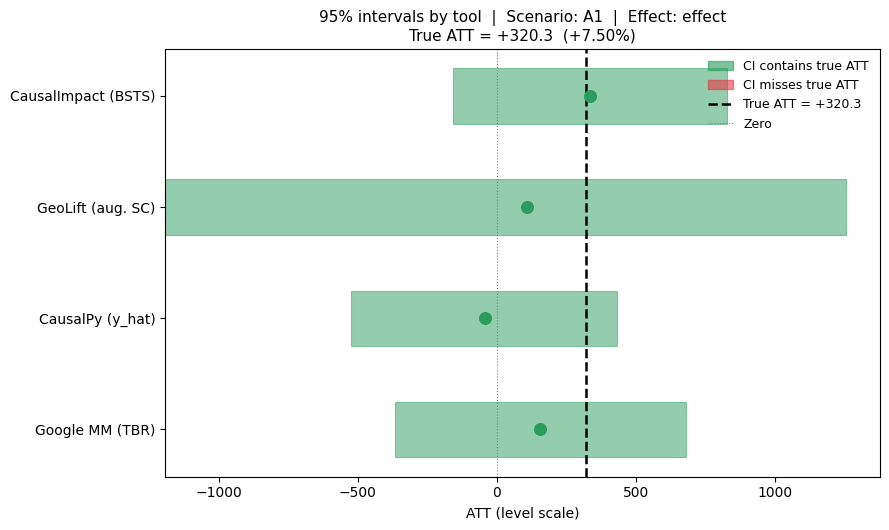

In [12]:
# ── Summary table ──────────────────────────────────────────────────────────────
rows = []
for tool_name, res in tool_results.items():
    att_l = res.get('att_level')
    ci_lo = res.get('ci_lower_level')
    ci_hi = res.get('ci_upper_level')
    contains = (
        check_coverage(ci_lo, ci_hi, true_att_level)
        if (ci_lo is not None and ci_hi is not None)
        else False
    )
    # Recompute ATT% with the true counterfactual denominator (equalization protocol)
    att_pct_unified = (
        att_l / true_cf_mean * 100
        if (att_l is not None and true_cf_mean != 0)
        else None
    )
    ci_width = (ci_hi - ci_lo) if (ci_lo is not None and ci_hi is not None) else None

    rows.append({
        'Tool':         tool_name,
        'ATT (level)':  f'{att_l:+.2f}' if att_l is not None else '--',
        'ATT (%)':      f'{att_pct_unified:+.2f}%' if att_pct_unified is not None else '--',
        'CI lower':     f'{ci_lo:+.2f}' if ci_lo is not None else '--',
        'CI upper':     f'{ci_hi:+.2f}' if ci_hi is not None else '--',
        'CI width':     f'{ci_width:.2f}' if ci_width is not None else '--',
        'Covers true':  'Yes' if contains else 'No',
        'Significant':  'Yes' if res.get('significant') else 'No',
    })

print(f'True ATT (level): {true_att_level:+.2f}  |  True ATT (%): {true_att_pct * 100:+.2f}%')
print()
display(pd.DataFrame(rows).set_index('Tool'))

# ── Horizontal CI plot ─────────────────────────────────────────────────────────
valid = [
    (name, r) for name, r in tool_results.items()
    if r.get('ci_lower_level') is not None and r.get('ci_upper_level') is not None
]

if not valid:
    print('No valid results to plot.')
else:
    fig, ax = plt.subplots(figsize=(9, 0.9 * len(valid) + 1.8))

    for i, (tool_name, res) in enumerate(valid):
        ci_lo = res['ci_lower_level']
        ci_hi = res['ci_upper_level']
        att_l = res['att_level']
        contains = check_coverage(ci_lo, ci_hi, true_att_level)
        color = '#2a9d5c' if contains else '#e63946'

        ax.barh(i, ci_hi - ci_lo, left=ci_lo, height=0.5,
                color=color, alpha=0.5, edgecolor=color, linewidth=0.8)
        if att_l is not None:
            ax.scatter(att_l, i, color=color, s=70, zorder=5)

    ax.axvline(true_att_level, color='black', lw=1.8, ls='--')
    ax.axvline(0, color='gray', lw=0.8, ls=':')

    ax.set_yticks(range(len(valid)))
    ax.set_yticklabels([name for name, _ in valid], fontsize=10)
    ax.set_xlabel('ATT (level scale)', fontsize=10)
    ax.set_title(
        f'95% intervals by tool  |  Scenario: {SCENARIO}  |  Effect: {EFFECT}\n'
        f'True ATT = {true_att_level:+.1f}  ({true_att_pct * 100:+.2f}%)',
        fontsize=11,
    )

    legend_handles = [
        mpatches.Patch(color='#2a9d5c', alpha=0.6, label='CI contains true ATT'),
        mpatches.Patch(color='#e63946', alpha=0.6, label='CI misses true ATT'),
        plt.Line2D([0], [0], color='black', lw=1.8, ls='--',
                   label=f'True ATT = {true_att_level:+.1f}'),
        plt.Line2D([0], [0], color='gray', lw=0.8, ls=':', label='Zero'),
    ]
    ax.legend(handles=legend_handles, fontsize=9, frameon=False, loc='upper right')
    fig.tight_layout()
    plt.show()